In [1]:
# ==================
# Imports and Setup
# =================

# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Soil Theme Palette
PALETTE = {
    "clay_brown": "#8B5A2B",
    "deep_brown": "#5A3E2B",
    "green": "#2E7D32",
    "blue": "#1E88E5",
    "red": "#8B0000",
    "orange": "#F57C00",
    "yellow": "#FBC02D",
    "sand": "#F5E6C4",
    "charcoal": "#2B2B2B"
}

# Global style
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.facecolor": PALETTE["sand"],
    "figure.facecolor": PALETTE["sand"],
    "axes.edgecolor": PALETTE["charcoal"],
    "axes.labelcolor": PALETTE["charcoal"],
    "xtick.color": PALETTE["charcoal"],
    "ytick.color": PALETTE["charcoal"],
    "text.color": PALETTE["charcoal"],
    "axes.titleweight": "bold"
})


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [3]:
# load data
df = pd.read_csv("clay_clean.csv")
df.head()

,longitude,latitude,profile_id,layer_id,profile_code,layer_name,upper_depth,lower_depth,organic_surface,value,...,dataset_id,country_name,positional_uncertainty,region,continent,date,licence,depth_mid,depth_thickness,depth_category
0,26.09778,-30.145280,590355,146621,ZA SOTER_6076,B,30,90,0,NaN,...,AF-AfSP,South Africa,Circa 100 m,Southern Africa,Africa,1973-3-1,Attribution-NonCommercial 3.0 International (C...,60.0,60,Deep
1,30.02350,-27.592199,574310,2910210,icr048468,NaN,0,20,0,NaN,...,AF-AfSIS-I,South Africa,Circa 100 m,Southern Africa,Africa,????-??-??,"Attribution 4.0 International (CC BY 4.0), htt...",10.0,20,Surface
2,26.04667,-28.983330,590352,146613,ZA SOTER_104,C,90,100,0,NaN,...,AF-AfSP,South Africa,Circa 100 m,Southern Africa,Africa,1973-5-1,Attribution-NonCommercial 3.0 International (C...,95.0,10,Deep
3,29.87667,-27.588330,590646,147482,ZA SOTER_4394,B,20,80,0,NaN,...,AF-AfSP,South Africa,Circa 100 m,Southern Africa,Africa,1978-10-1,Attribution-NonCommercial 3.0 International (C...,50.0,60,Mid
4,29.30556,-26.208330,590604,147358,ZA SOTER_1790,A,0,45,0,NaN,...,AF-AfSP,South Africa,Circa 100 m,Southern Africa,Africa,1973-8-1,Attribution-NonCommercial 3.0 International (C...,22.5,45,Mid


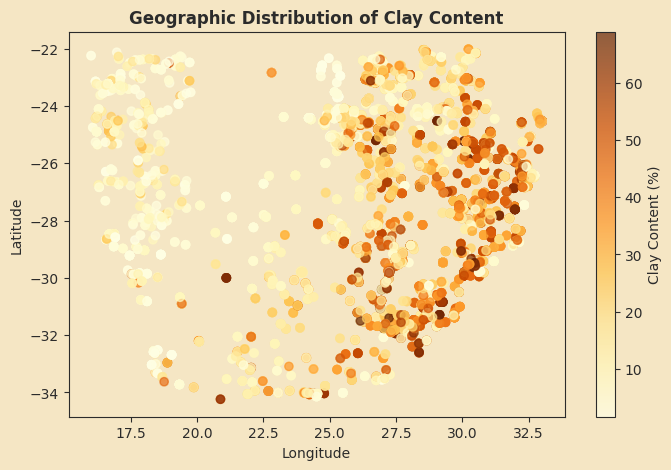

In [7]:
# Geo Scatter

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['value_avg'],
    cmap='YlOrBr',
    alpha=0.7
)

plt.colorbar(label="Clay Content (%)")

plt.title("Geographic Distribution of Clay Content")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

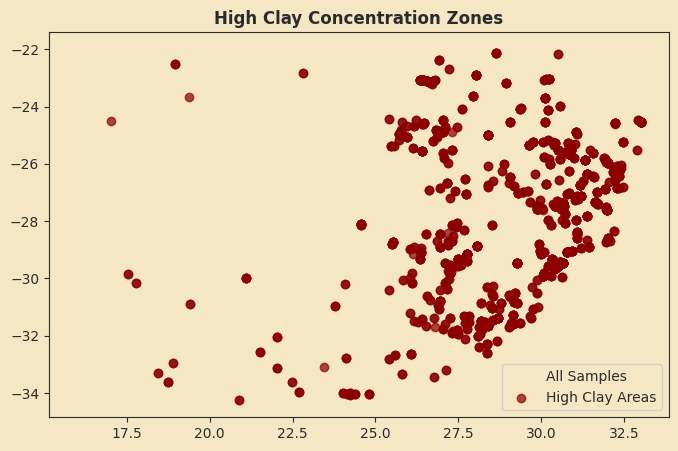

In [11]:
# High Clay Regions

high_clay = df[df['value_avg'] > df['value_avg'].quantile(0.75)]

plt.scatter(
    df['longitude'],
    df['latitude'],
    color=PALETTE["sand"],
    alpha=0.3,
    label="All Samples"
)

plt.scatter(
    high_clay['longitude'],
    high_clay['latitude'],
    color=PALETTE["red"],
    alpha=0.7,
    label="High Clay Areas"
)

plt.legend()
plt.title("High Clay Concentration Zones")
plt.show()

NameError: name 'clean_plot' is not defined

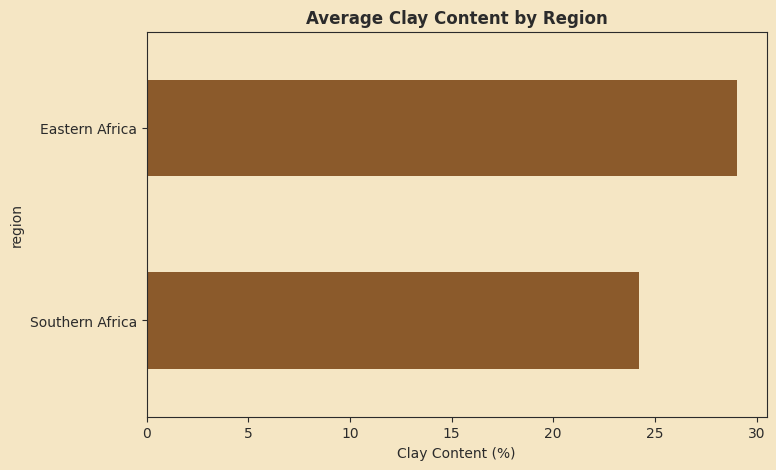

In [13]:
# Regional Aggregation

region_stats = df.groupby('region')['value_avg'].mean().sort_values()

region_stats.plot(
    kind='barh',
    color=PALETTE["clay_brown"]
)

plt.title("Average Clay Content by Region")
plt.xlabel("Clay Content (%)")

clean_plot()
plt.show()

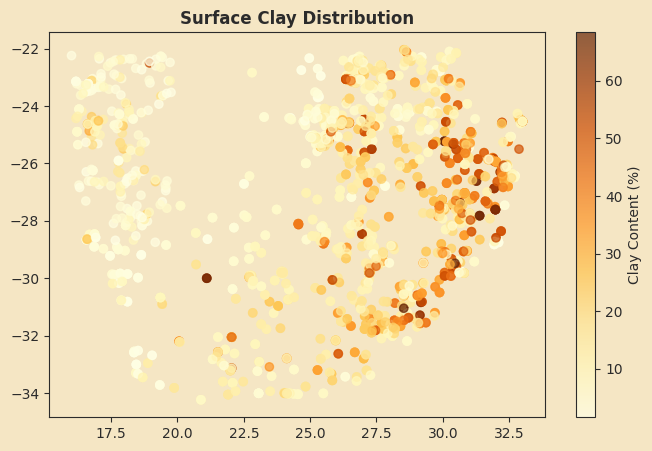

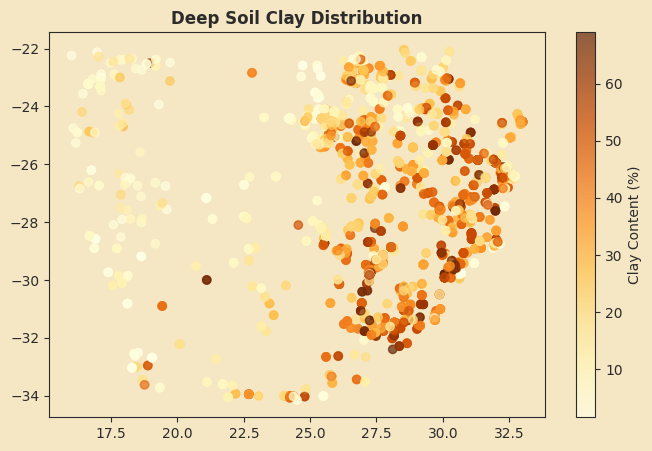

In [15]:
# =========================
# Surface vs. Deep Mapping
# ========================

# Define Depth Regions
surface = df[df['depth_category'] == "Surface"]
deep = df[df['depth_category'] == "Deep"]

# Surface Plot
plt.scatter(
    surface['longitude'],
    surface['latitude'],
    c=surface['value_avg'],
    cmap='YlOrBr',
    alpha=0.7
)

plt.title("Surface Clay Distribution")
plt.colorbar(label="Clay Content (%)")
plt.show()


# Deep Map
plt.scatter(
    deep['longitude'],
    deep['latitude'],
    c=deep['value_avg'],
    cmap='YlOrBr',
    alpha=0.7
)

plt.title("Deep Soil Clay Distribution")
plt.colorbar(label="Clay Content (%)")
plt.show()